<a href="https://colab.research.google.com/github/PavitraMutyala/Major-Project-II-SemVIII-/blob/main/FY_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cardio_train.csv to cardio_train (1).csv


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("cardio_train.csv", delimiter=";")

# Display basic info
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


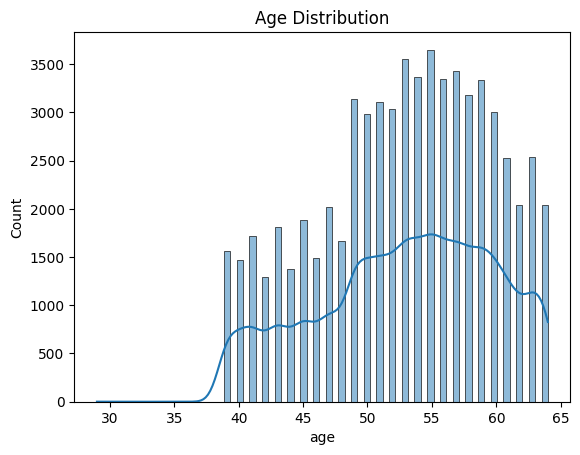

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Drop 'id' column
df.drop(columns=['id'], inplace=True)

# Convert age from days to years
df['age'] = df['age'] // 365

# Create BMI feature
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# Remove outliers in blood pressure, height, and weight
df = df[(df['ap_hi'] > 90) & (df['ap_hi'] < 180)]
df = df[(df['ap_lo'] > 60) & (df['ap_lo'] < 120)]
df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 40) & (df['weight'] < 180)]

# Visualization: Distribution of Age
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


In [ ]:
# Define features & target variable
X = df.drop(columns=['cardio'])
y = df['cardio']

# Identify categorical & numerical features
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
numerical_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

# Preprocessing: Standardize numerical features & encode categorical ones
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X = preprocessor.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.7248857563318101


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7259701030129347


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Build Deep Learning Model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1614/1614 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7089 - loss: 0.5767 - val_accuracy: 0.7230 - val_loss: 0.5619
Epoch 2/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7257 - loss: 0.5577 - val_accuracy: 0.7268 - val_loss: 0.5591
Epoch 3/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7307 - loss: 0.5497 - val_accuracy: 0.7264 - val_loss: 0.5570
Epoch 4/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7314 - loss: 0.5491 - val_accuracy: 0.7271 - val_loss: 0.5564
Epoch 5/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7327 - loss: 0.5478 - val_accuracy: 0.7251 - val_loss: 0.5560
Epoch 6/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7322 - loss: 0.5498 - val_accuracy: 0.7245 - val_loss: 0.5562
Epoch 7/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7314 - loss: 0.5504 - val_accuracy: 0.7249 - val_loss: 0.5582
Epoch 8/20
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7298 - loss: 0.5484 - val_accur

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Deep Learning Model Accuracy:", test_acc)


404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7300 - loss: 0.5543
Deep Learning Model Accuracy: 0.7255054116249084


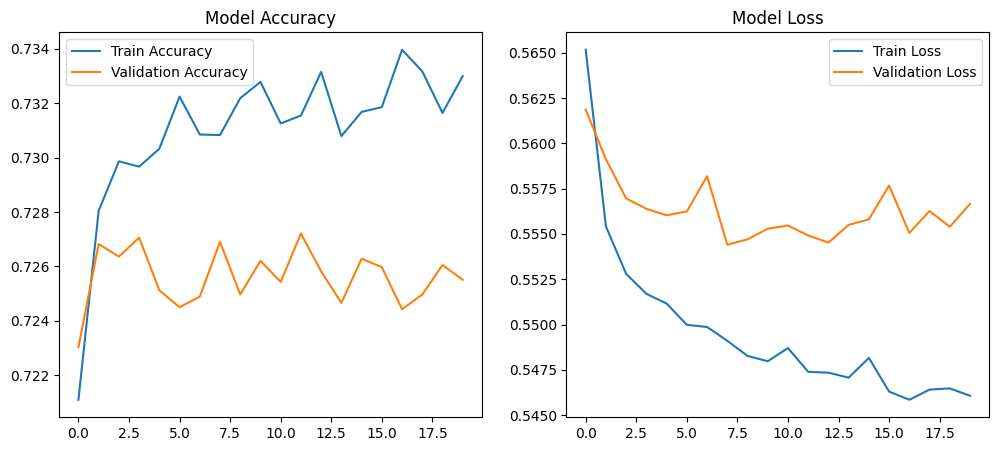

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.legend()

plt.show()


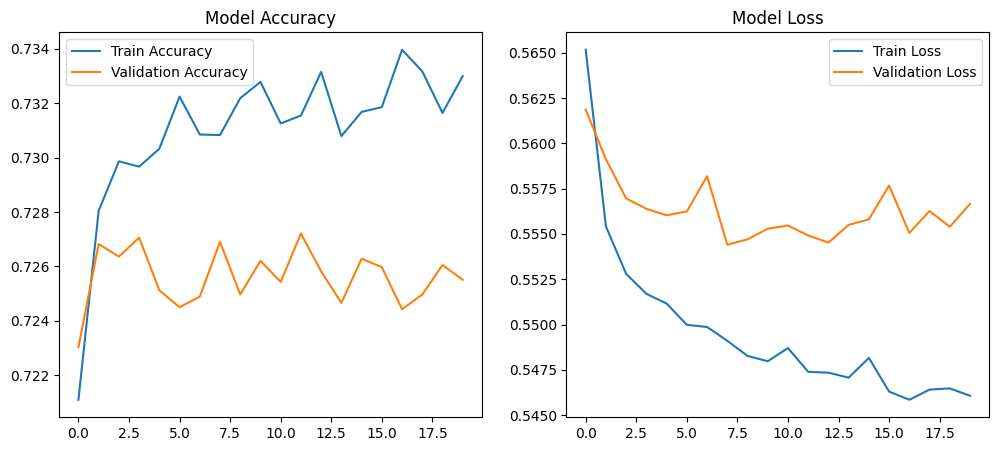

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.legend()

plt.show()


In [ ]:
import joblib

# Save ML Models
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")

# Save Deep Learning Model
model.save("deep_learning_model.h5")


In [ ]:
from google.colab import files
files.download("random_forest_model.pkl")
files.download("xgboost_model.pkl")
files.download("deep_learning_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>